<a href="https://colab.research.google.com/github/dusandvorakcz-png/EDA-Pharma-Sales-Data-2014-2019/blob/main/EDA_Pharma_Sales_Data_2014_2019.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LIBRARY SET UP
* Importing necessary libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# LOADING AND DEFINING THE DATA FRAME


*   Parsing the "datum" column as dates and indexing it so it is treated as a time series.

In [2]:
df = pd.read_csv("salesmonthly.csv", parse_dates=["datum"])
df = df.set_index("datum")
df = df.rename_axis('Date')
df

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
Date,,,,,,,,
2014-01-31,127.69,99.090,152.100,878.030,354.0,50.0,112.0,48.20
2014-02-28,133.32,126.050,177.000,1001.900,347.0,31.0,122.0,36.20
2014-03-31,137.44,92.950,147.655,779.275,232.0,20.0,112.0,85.40
2014-04-30,113.10,89.475,130.900,698.500,209.0,18.0,97.0,73.70
2014-05-31,101.79,119.933,132.100,628.780,270.0,23.0,107.0,123.70
...,...,...,...,...,...,...,...,...
2019-06-30,151.54,101.627,103.200,610.000,193.0,25.0,142.0,156.04
2019-07-31,181.00,103.541,92.800,649.800,250.6,20.0,115.0,105.20
2019-08-31,181.91,88.269,84.200,518.100,237.0,26.0,145.0,97.30


# DATA DICTIONARY
* **M01AB** — Painkillers that also reduce inflammation and swelling (the "non-steroid" kind, not like cortisone). Includes drugs like diclofenac, often used for joint and muscle pain.
* **M01AE** — The same family of anti-inflammatory painkillers, just a slightly different chemical type. This is the group that includes ibuprofen — the everyday pain and fever reliever most people recognise.
* **N02BA** — General pain and fever relievers based on aspirin and its relatives. Used for headaches, minor aches, and fever (and in low doses, for the heart).
* **N02BE** — Other pain and fever relievers, most notably paracetamol (acetaminophen / Tylenol). Common for headaches and fever, and gentler on the stomach than the anti-inflammatory types above.
* **N05B** — Anti-anxiety medications (anxiolytics). Calming drugs used to reduce anxiety and tension — for example, diazepam-type medicines.
* **N05C** — Sleeping aids and sedatives (hypnotics). Drugs that help people fall asleep or stay calm, closely related to the anxiety group above.
* **R03** — Asthma and breathing medications. Treat conditions where the airways narrow, such as asthma or COPD — inhalers fall into this group.
* **R06** — Antihistamines (the "allergy" group). Used for hay fever, allergic reactions, and sometimes as a sleep aid.

The first letter is the body system the drug acts on. M = musculoskeletal (muscles and joints), N = nervous system (brain), R = respiratory (breathing).



# DATA QUALITY AND CLEANING


Before starting, I checked the data for missing values, duplicate or
out-of-order dates, negative quantities, and anything that didn't look realistic. It was mostly clean, but I removed two months.

**January 2017** shows zero sales for every drug group except a single unit of N05B.
A pharmacy selling nothing for a whole month isn't realistic, and that value looks like a recording or imputation issue rather than a real sale. I treated the month as missing and removed it, since leaving it in drags every
category's minimum down to a fake zero.

**October 2019** is the last month and sits at only 15 to 40% of every other
October. To check whether it was just a low month, I went to the daily file:
every October from 2014 to 2018 has 31 days of records, but October 2019 has
only 8, then the data stops. It's a partial month, not low demand, so I removed it.

That leaves 68 complete months (January 2014 to September 2019), with no missing values, no duplicate dates, correct ordering, and no negative quantities.



In [3]:
daily = pd.read_csv("salesdaily.csv", parse_dates=["datum"])
daily = daily.set_index("datum")
daily = daily.rename_axis('Date')

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 70 entries, 2014-01-31 to 2019-10-31
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   M01AB   70 non-null     float64
 1   M01AE   70 non-null     float64
 2   N02BA   70 non-null     float64
 3   N02BE   70 non-null     float64
 4   N05B    70 non-null     float64
 5   N05C    70 non-null     float64
 6   R03     70 non-null     float64
 7   R06     70 non-null     float64
dtypes: float64(8)
memory usage: 4.9 KB


,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
count,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000,70.000000
mean,149.992000,116.514286,115.020843,892.542071,262.118571,17.842857,167.675000,86.662571
std,31.485325,27.889336,31.245899,338.843908,85.060930,8.481242,81.767979,45.859336
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,137.490000,103.518250,94.375000,648.187500,223.750000,12.000000,112.000000,49.875000
50%,154.635000,114.840000,117.225000,865.824500,250.300000,18.000000,160.000000,74.100000
75%,169.000000,128.359750,133.837500,1061.580000,293.650000,23.000000,218.250000,119.807500
max,211.130000,222.351000,191.600000,1856.815000,492.000000,50.000000,386.000000,213.040000


In [5]:
df[(df==0).any(axis=1)]

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
Date,,,,,,,,
2017-01-31,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [6]:
df[df.index.year==2017]

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
Date,,,,,,,,
2017-01-31,0.00,0.000,0.00,0.000,1.0,0.0,0.0,0.00
2017-02-28,139.69,103.517,97.00,526.350,144.0,7.0,117.0,30.60
2017-03-31,162.85,111.055,107.35,612.500,165.0,9.0,139.0,100.10
2017-04-30,155.61,101.215,100.50,540.200,132.0,9.0,209.0,122.40
2017-05-31,143.66,118.125,98.95,547.940,148.0,23.0,128.0,161.81
2017-06-30,122.33,103.006,119.60,496.100,163.0,8.0,163.0,151.90
2017-07-31,159.67,116.206,75.20,479.350,219.0,15.0,115.0,81.10
2017-08-31,170.15,112.470,84.40,549.300,239.0,12.0,75.0,60.10
2017-09-30,138.33,118.711,88.15,863.750,223.0,23.0,139.0,66.90


In [7]:
df = df.drop(index="2017-01-31", errors="ignore")

In [8]:
df[df.index.year==2017]

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
Date,,,,,,,,
2017-02-28,139.69,103.517,97.00,526.350,144.0,7.0,117.0,30.60
2017-03-31,162.85,111.055,107.35,612.500,165.0,9.0,139.0,100.10
2017-04-30,155.61,101.215,100.50,540.200,132.0,9.0,209.0,122.40
2017-05-31,143.66,118.125,98.95,547.940,148.0,23.0,128.0,161.81
2017-06-30,122.33,103.006,119.60,496.100,163.0,8.0,163.0,151.90
2017-07-31,159.67,116.206,75.20,479.350,219.0,15.0,115.0,81.10
2017-08-31,170.15,112.470,84.40,549.300,239.0,12.0,75.0,60.10
2017-09-30,138.33,118.711,88.15,863.750,223.0,23.0,139.0,66.90
2017-10-31,137.64,88.737,100.40,1184.350,226.0,15.0,247.0,51.00


In [9]:
df.idxmin()

,0
M01AB,2019-10-31
M01AE,2019-10-31
N02BA,2019-10-31
N02BE,2019-10-31
N05B,2019-10-31
N05C,2015-04-30
R03,2014-08-31
R06,2019-10-31


In [10]:
df[(df.index.month == 10) & (df.index.year == 2019)]

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
Date,,,,,,,,
2019-10-31,44.37,37.3,20.65,295.15,86.0,7.0,37.0,11.13


In [11]:
df.index.year.value_counts()

,count
Date,
2014,12
2015,12
2016,12
2018,12
2017,11
2019,10


In [12]:
oct_daily = daily[daily.index.month == 10]
oct_daily.groupby(oct_daily.index.year).size()

,0
Date,
2014,31
2015,31
2016,31
2017,31
2018,31
2019,8


In [13]:
df = df.drop(index="2019-10-31", errors="ignore")

In [14]:
df[df.index.month==10]

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
Date,,,,,,,,
2014-10-31,154.75,185.241,191.60,1856.815,472.0,30.0,182.0,74.5
2015-10-31,195.81,127.231,146.20,1574.335,222.0,8.0,184.0,72.0
2016-10-31,186.76,142.056,160.15,1617.275,312.0,11.0,220.0,60.9
2017-10-31,137.64,88.737,100.40,1184.350,226.0,15.0,247.0,51.0
2018-10-31,144.71,129.400,76.05,1129.275,287.0,25.0,353.0,76.9


In [15]:
df.describe()

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
count,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000,68.000000
mean,153.751029,119.392647,118.100132,914.452868,268.548529,18.264706,172.062500,89.047794
std,22.456262,22.278891,25.796187,317.078410,76.998536,8.209237,78.686445,44.303900
min,101.790000,88.269000,75.200000,479.350000,132.000000,5.000000,37.000000,30.600000
25%,137.970000,103.536250,98.462500,651.721500,226.000000,12.000000,114.250000,51.150000
50%,155.180000,114.976500,118.675000,872.964500,251.400000,18.000000,162.000000,75.700000
75%,169.407500,128.648000,133.937500,1068.227000,296.250000,23.000000,219.250000,121.150000
max,211.130000,222.351000,191.600000,1856.815000,492.000000,50.000000,386.000000,213.040000


Text(0, 0.5, 'Units sold')

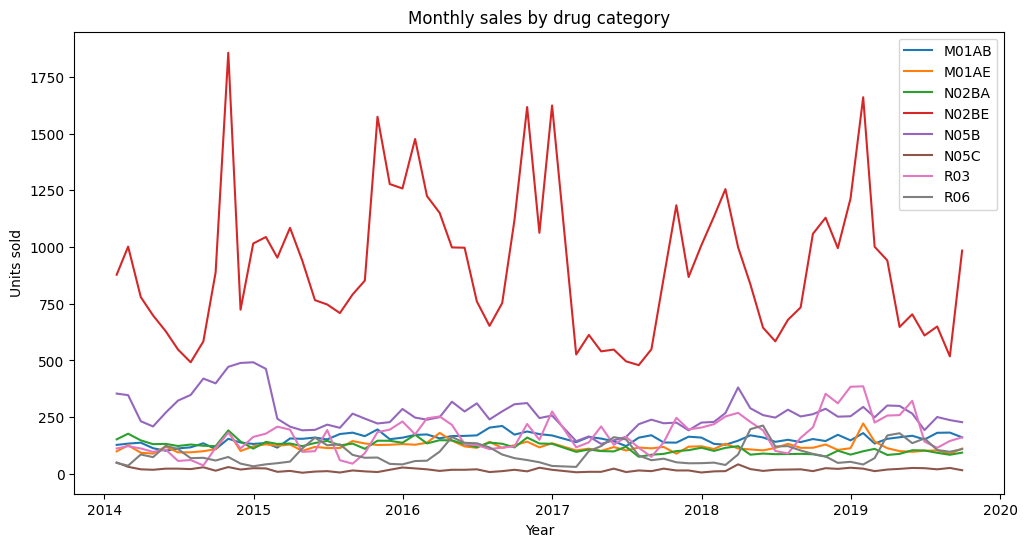

In [16]:
plt.figure(figsize=(12,6))

sns.lineplot(data=df,
             dashes = False
             )

plt.title("Monthly sales by drug category")
plt.xlabel("Year")
plt.ylabel("Units sold")

A line plot with all categories together is hard to read because N02BE sells far more than the others, which flattens the rest. In the next chart I break the sales down by drug so each one is easier to see.

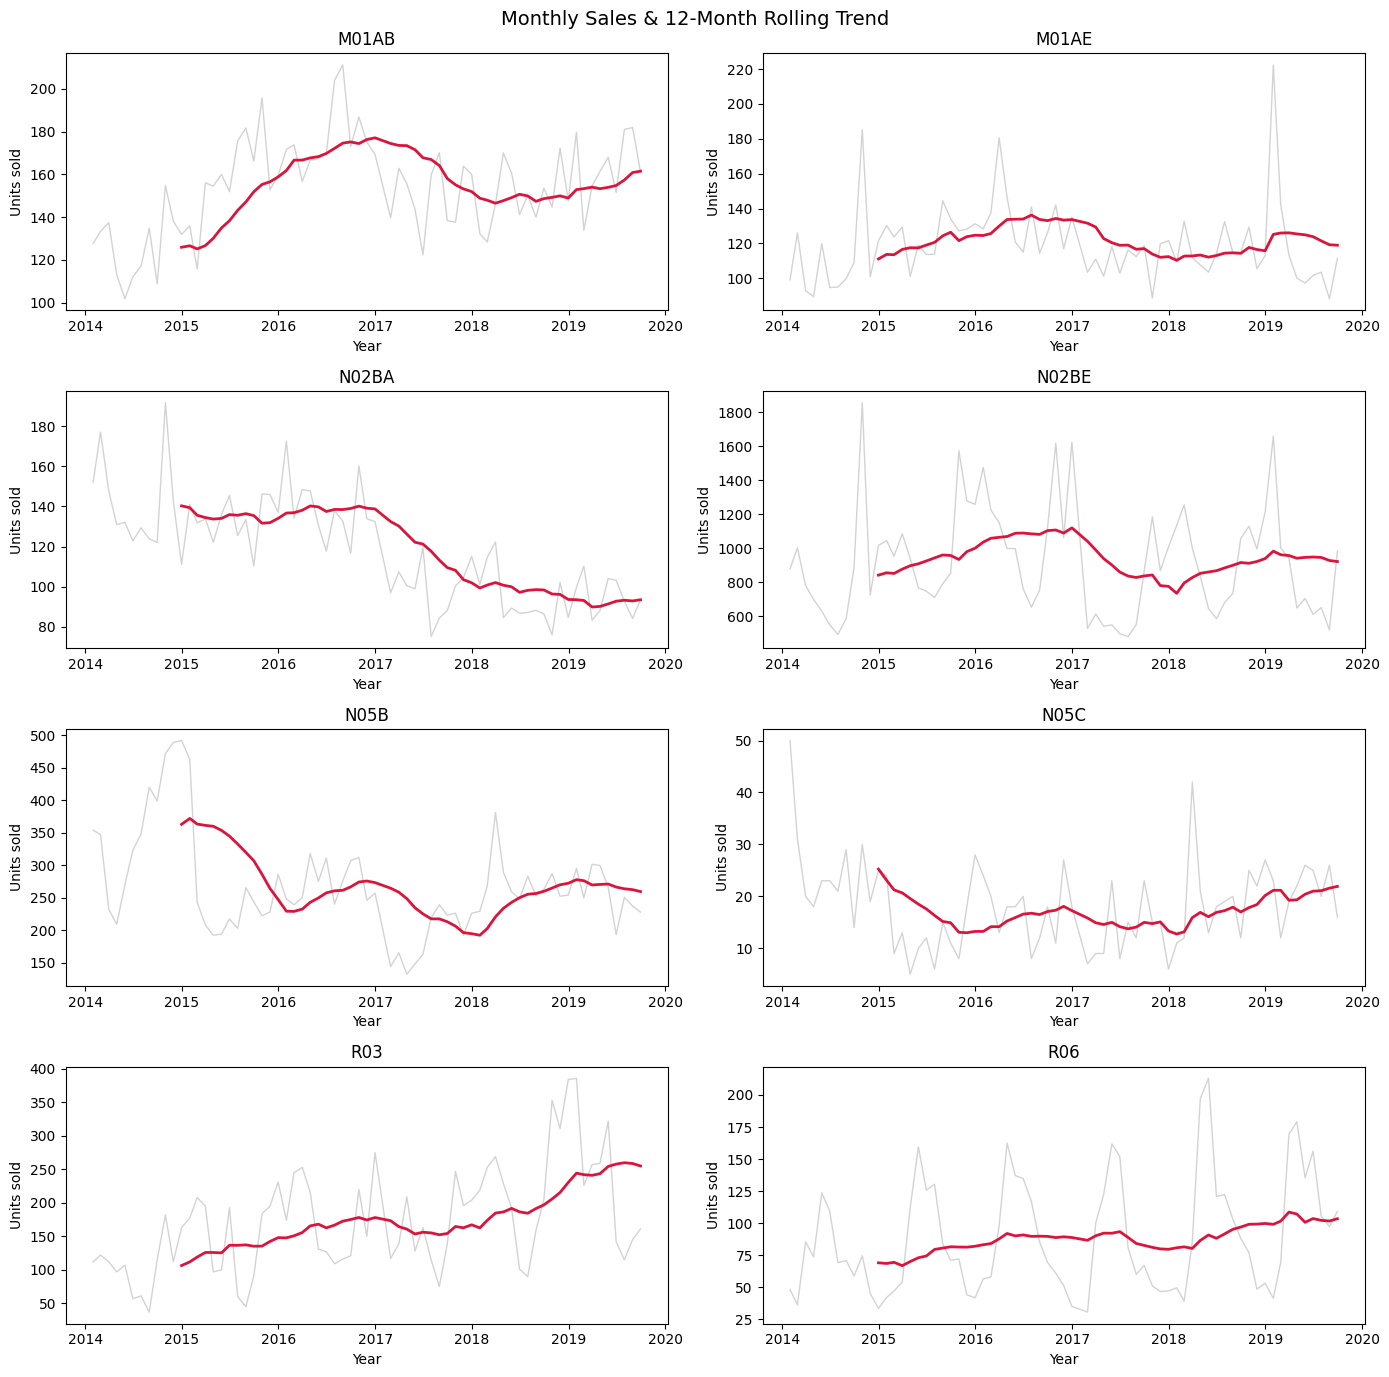

In [17]:
fig, axes = plt.subplots(4, 2, figsize=(14, 14))

for col, ax in zip(df.columns, axes.flatten()):
    ax.plot(df.index, df[col], color="lightgray", linewidth=1)
    ax.plot(df.index, df[col].rolling(12).mean(), color="crimson", linewidth=2)
    ax.set_title(col)
    ax.set_xlabel("Year")
    ax.set_ylabel("Units sold")

fig.suptitle("Monthly Sales & 12-Month Rolling Trend", fontsize=14)
plt.tight_layout()
plt.show()

Looking at the red trend lines, each drug tells a different story:

* **M01AB** went up from 2014 to 2016 and then flattened out.
* **N02BA** and **N05B** both dropped over time, especially N02BA, which went down quite steadily.
* **R03** is the clearest winner here, showing a big jump from 2018 onward.
* **N02BE** stays mostly flat on average, but its monthly numbers jump up and down a lot.
* **R06** doesn't change much overall, but it has a strong, repeating wave pattern. This means its sales are seasonal rather than growing.
* **N05C** sales are very low and messy, so it’s hard to tell if there is a real trend there at all.

In [18]:
df.groupby(df.index.month).mean()

,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
Date,,,,,,,,
1,149.446000,137.927600,133.290000,1238.706200,317.840000,26.400000,213.650000,47.500000
2,137.436667,127.632333,127.480000,993.825000,248.400000,15.166667,195.166667,46.726667
3,152.275000,123.143667,123.809167,927.916333,256.233333,19.333333,204.166667,98.723333
4,153.538333,107.703167,112.316667,776.815667,239.900000,15.500000,184.500000,141.116667
5,150.231667,113.136000,115.190000,714.663333,235.300000,18.833333,163.333333,155.091667
6,141.443333,107.036667,115.951667,624.251000,242.500000,17.666667,130.500000,133.106667
7,164.581667,117.022500,107.983333,610.265000,257.266667,14.833333,91.666667,104.121667
8,169.945000,112.355333,107.791667,654.821000,281.666667,19.000000,96.166667,83.383333
9,150.146667,119.095667,102.891667,960.856000,277.216667,15.666667,138.666667,77.200000


A quick look at the monthly averages for all categories together. N02BE dominates again, so the next chart breaks each one out to see the seasonal shapes clearly.

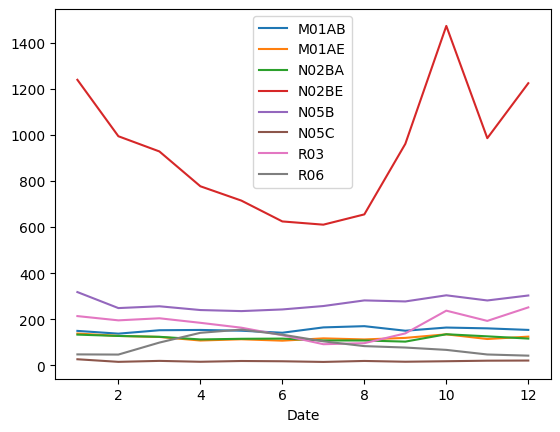

In [19]:
monthly_avg = df.groupby(df.index.month).mean()

sns.lineplot(data=monthly_avg, dashes=False)
plt.show()

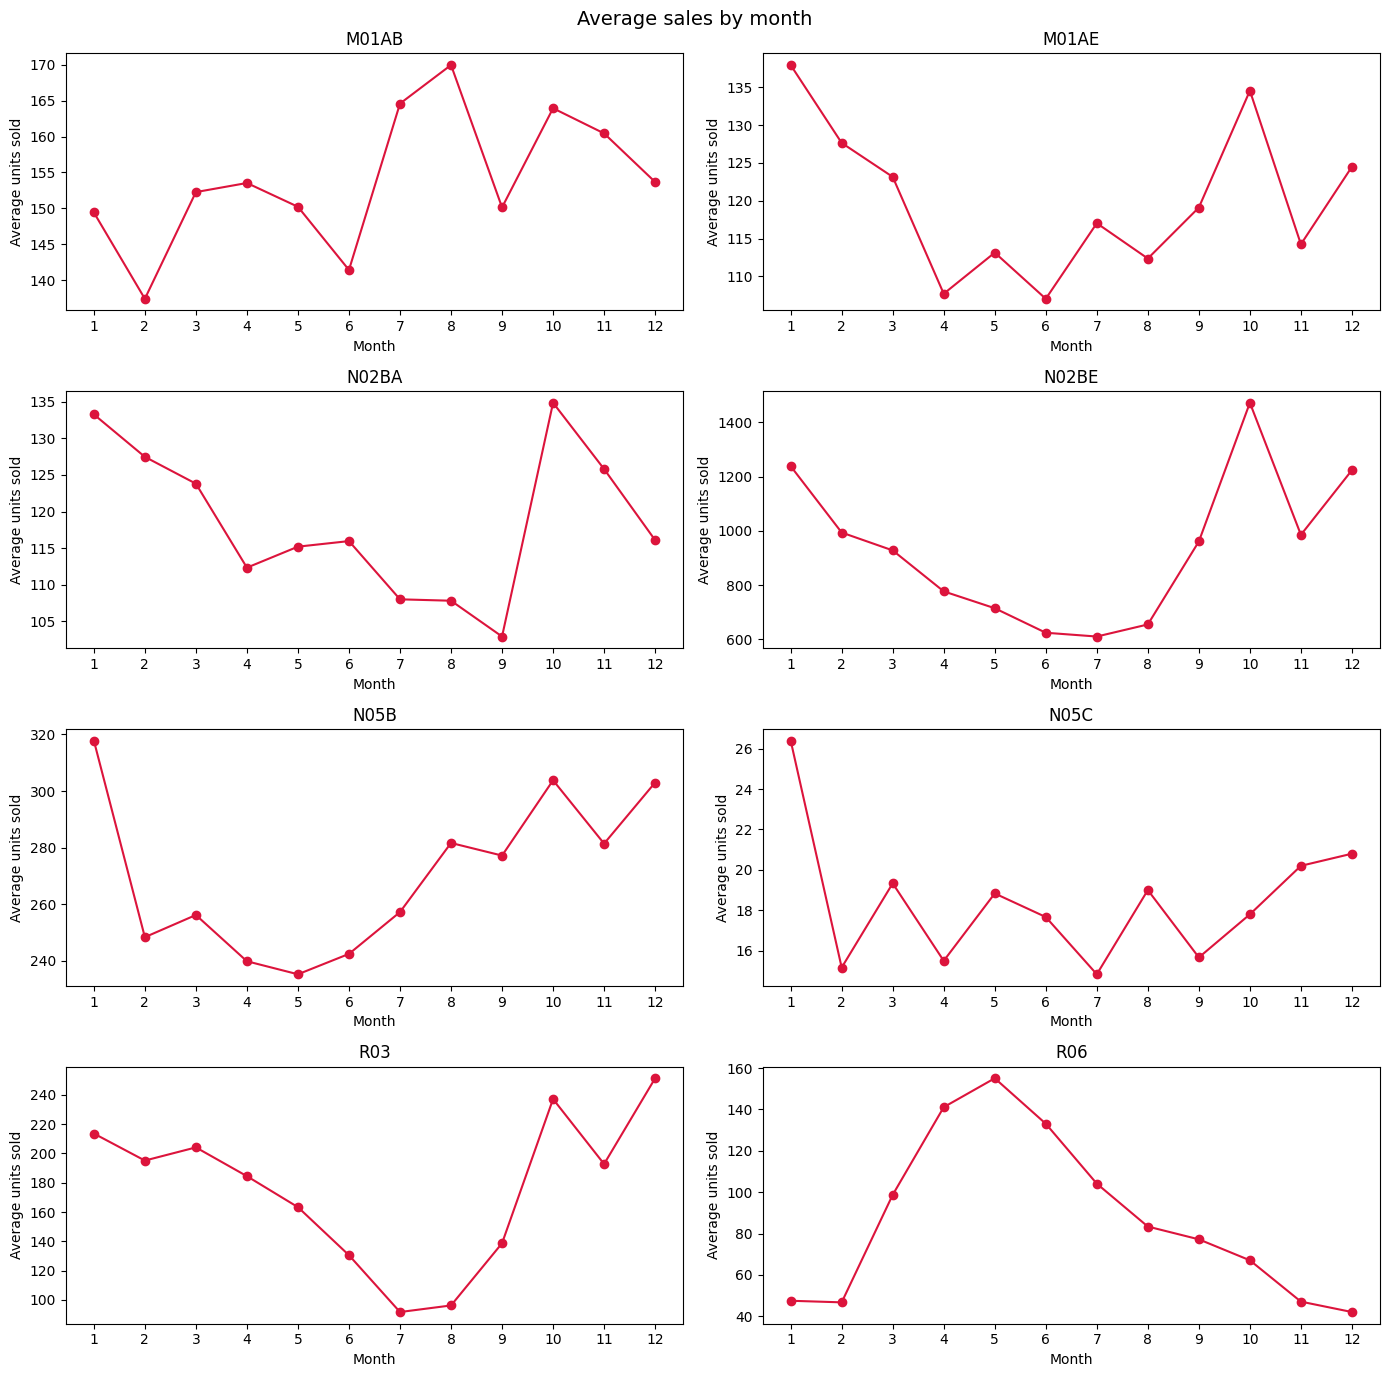

In [20]:
monthly_avg = df.groupby(df.index.month).mean()

fig, axes = plt.subplots(4, 2, figsize=(14, 14))

for col, ax in zip(monthly_avg.columns, axes.flatten()):
    ax.plot(monthly_avg.index, monthly_avg[col], marker="o", color="crimson")
    ax.set_title(col)
    ax.set_xlabel("Month")
    ax.set_ylabel("Average units sold")
    ax.set_xticks(range(1, 13))

fig.suptitle("Average sales by month", fontsize=14)
plt.tight_layout()
plt.show()

I averaged the data for each calendar month across all the years to look for seasonal patterns. It shows when people need certain medications the most:

* **R06 (Allergy Meds):** This one shoots up sharply in the spring, hitting a peak around May, and drops to its lowest point in the winter. This perfectly matches the timing for hay fever and allergy season.
* **N02BE (Pain and Fever Meds):** This does the exact opposite. It hits its highest peak during the middle of winter (December and January) and bottoms out in the summer, which lines up perfectly with the winter cold and flu season.
* **N02BA, N05B, and R03:** These three follow a very similar winter-high, summer-low shape, meaning they are also likely driven by winter ailments.
* **M01AB and N05C:** M01AB behaves a bit differently, peaking in the late summer, while N05C stays mostly flat and steady all year round without any real seasonal swings.

Two biggest and most obvious takeaways here are the opposite lifecycles of allergy medication (which dominates the spring) and cold/flu remedies (which dominate the winter).

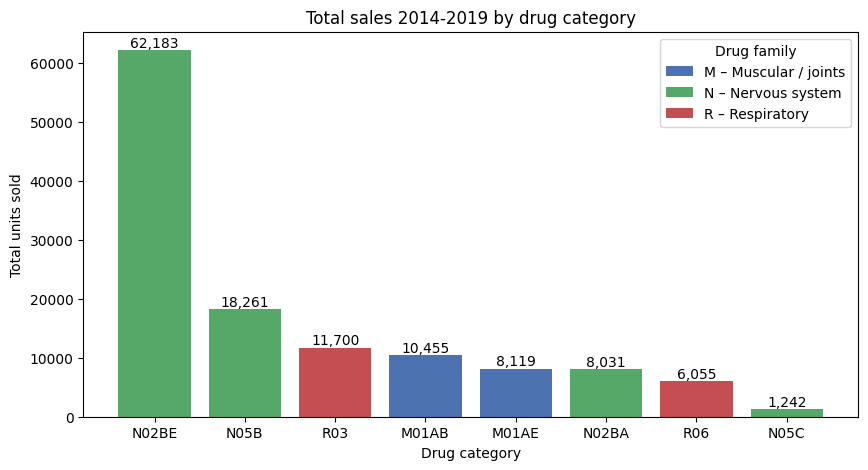

In [21]:
totals = df.sum().sort_values(ascending=False)

palette = {"M": "#4C72B0", "N": "#55A868", "R": "#C44E52"}
colors = [palette[c[0]] for c in totals.index]

plt.figure(figsize=(10, 5))
bars = plt.bar(totals.index, totals.values, color=colors)
plt.title("Total sales 2014-2019 by drug category")
plt.xlabel("Drug category")
plt.ylabel("Total units sold")

plt.bar_label(bars, labels=[f"{v:,.0f}" for v in totals.values])
legend_items = [
    Patch(facecolor="#4C72B0", label="M – Muscular / joints"),
    Patch(facecolor="#55A868", label="N – Nervous system"),
    Patch(facecolor="#C44E52", label="R – Respiratory"),
]
plt.legend(handles=legend_items, title="Drug family")
plt.show()

N02BE sells far more than any other category over the whole period, which is why it dominates the combined line chart. The pain and fever groups (N02BE, M01AB, N02BA, M01AE) make up most of the volume, while the sleep and allergy groups (N05C, R06) are much smaller.

# KEY FINDINGS

After cleaning the data to 68 complete months (2014–2019), a few clear patterns stand out:

* **Sales are strongly seasonal.** Allergy medication (R06) peaks in spring around
  May, while cold and flu medication (N02BE) peaks in winter. The two move in
  opposite directions across the year.

* **Trends differ by category.** R03 (respiratory) is clearly rising, especially
  from 2018, while N02BA and N05B are declining. Most others are fairly flat.

* **One category dominates volume.** N02BE (paracetamol-type painkillers) sells far
  more than any other group, so overall sales are heavily driven by it.

* **The categories are mostly independent.** Most drug groups don't move closely
  together. The main exceptions are the two everyday painkillers (N02BE and M01AE),
  which rise and fall together, and allergy versus cold/flu meds, which move in
  opposite directions, matching the seasonal finding.

Two months were unusable (a corrupt January 2017 and a partial October 2019) and were removed before analysis.